<a href="https://colab.research.google.com/github/Satya-789/Movie-Recommendation-System/blob/main/Project_Movie_Recommendation__System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''

The first dataset "credits.csv" contains the following features:-

movie_id - A unique identifier for each movie.
cast - The name of lead and supporting actors.
crew - The name of Director, Editor, Composer, Writer etc.



The second dataset "movies.csv" has the following features:-

budget - The budget in which the movie was made.
genre - The genre of the movie, Action, Comedy ,Thriller etc.
homepage - A link to the homepage of the movie.
id - This is infact the movie_id as in the first dataset.
keywords - The keywords or tags related to the movie.
original_language - The language in which the movie was made.
original_title - The title of the movie before translation or adaptation.
overview - A brief description of the movie.
popularity - A numeric quantity specifying the movie popularity.
production_companies - The production house of the movie.
production_countries - The country in which it was produced.
release_date - The date on which it was released.
revenue - The worldwide revenue generated by the movie.
runtime - The running time of the movie in minutes.
status - "Released" or "Rumored".
tagline - Movie's tagline.
title - Title of the movie.
vote_average - average ratings the movie recieved.
vote_count - the count of votes recieved.

'''

In [2]:
credits = pd.read_csv(r"/tmdb_5000_credits.csv")

In [3]:
movies = pd.read_csv(r"/movies.csv")

In [4]:
credits.head(n=7)

,movie_id,title,cast,crew,Unnamed: 4
0,5,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",NaN
1,11,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN
2,12,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN
3,13,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN
4,14,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN
5,16,Spider-Man 3,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de...",NaN
6,18,Tangled,"[{""cast_id"": 34, ""character"": ""Flynn Rider (vo...","[{""credit_id"": ""52fe46db9251416c91062101"", ""de...",NaN


## 2.. Doing data Preparation !

In [5]:
movies.head(5)

,id,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,5,4000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 35, ""name...",NaN,"[{""id"": 612, ""name"": ""hotel""}, {""id"": 613, ""na...",en,Four Rooms,It's Ted the Bellhop's first night on the job....,22.876230,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",12/9/1995,4300000,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Twelve outrageous guests. Four scandalous requ...,Four Rooms,6.5,530
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",http://www.starwars.com/films/star-wars-episod...,"[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",5/25/1977,775398007,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"A long time ago in a galaxy far, far away...",Star Wars,8.1,6624
2,12,94000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",http://movies.disney.com/finding-nemo,"[{""id"": 494, ""name"": ""father son relationship""...",en,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",85.688789,"[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",5/30/2003,940335536,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"There are 3.7 trillion fish in the ocean, they...",Finding Nemo,7.6,6122
3,13,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",NaN,"[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",7/6/1994,677945399,142.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"The world will never be the same, once you've ...",Forrest Gump,8.2,7927
4,14,15000000,"[{""id"": 18, ""name"": ""Drama""}]",http://www.dreamworks.com/ab/,"[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29...",en,American Beauty,"Lester Burnham, a depressed suburban father in...",80.878605,"[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",9/15/1999,356296601,122.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Look closer.,American Beauty,7.9,3313


In [6]:
movies.columns

Index(['id', 'budget', 'genres', 'homepage', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [7]:
credits.columns

Index(['movie_id', 'title', 'cast', 'crew', 'Unnamed: 4'], dtype='object')

In [8]:
credits_updated_df = credits.rename(columns = {"movie_id" : "id"})

In [9]:
credits_updated_df

,id,title,cast,crew,Unnamed: 4
0,5,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",NaN
1,11,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN
2,12,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN
3,13,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN
4,14,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN
...,...,...,...,...,...
9598,464284,Scarlet Reckoning,"[{""cast_id"":1,""character"":""Director Bayoumi"",""...","[{""credit_id"":""32ce4096d40256dbeb75aaf0"",""depa...",NaN
9599,464285,Cascade Protocol: The Return,"[{""cast_id"":1,""character"":""Dr. Cheuk"",""credit_...","[{""credit_id"":""a67a937b7602db76d885c5b8"",""depa...",NaN
9600,464286,The Black Operation: The Final Chapter,"[{""cast_id"":1,""character"":""Thief"",""credit_id"":...","[{""credit_id"":""06aaf51b5f2b3e52eca1a456"",""depa...",NaN
9601,464287,The Lookout: Aftermath,"[{""cast_id"":1,""character"":""Clerk #18"",""credit_...","[{""credit_id"":""f78ce9669624557707649e05"",""depa...",NaN


In [10]:
movies.shape

(9603, 20)

In [11]:
credits_updated_df.shape

(9603, 5)

In [12]:
movies_df_merge = movies.merge(credits_updated_df,on="id")

In [13]:
movies_df_merge.shape

(9603, 24)

In [14]:
movies_df_merge.columns

Index(['id', 'budget', 'genres', 'homepage', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'title_y', 'cast', 'crew', 'Unnamed: 4'],
      dtype='object')

In [15]:
movies_cleaned_df = movies_df_merge.drop(columns = ['homepage' , 'title_x' , 'title_y' ,'status' , 'production_countries'])

In [16]:
movies_cleaned_df.head(2)

,id,budget,genres,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,Unnamed: 4
0,5,4000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 35, ""name...","[{""id"": 612, ""name"": ""hotel""}, {""id"": 613, ""na...",en,Four Rooms,It's Ted the Bellhop's first night on the job....,22.876230,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...",12/9/1995,4300000,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,6.5,530,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",NaN
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...","[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...",5/25/1977,775398007,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",8.1,6624,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN


## 3.. Understanding Average weighted Recommendation System !

In [17]:
movies_cleaned_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4'],
      dtype='object')

In [18]:
v = movies_cleaned_df['vote_count']
R = movies_cleaned_df['vote_average']
C = movies_cleaned_df['vote_average'].mean()

In [19]:
C
## mean rating for all the movies is approx 6.09 on a scale of 10

np.float64(6.066097218823389)

In [20]:
#### The next step is to determine an appropriate value for m ( minimum votes required to be listed in the chart)..

In [21]:
movies_cleaned_df[["original_title","vote_count"]]

,original_title,vote_count
0,Four Rooms,530
1,Star Wars,6624
2,Finding Nemo,6122
3,Forrest Gump,7927
4,American Beauty,3313
...,...,...
9598,The Blacksmith's Resonant Blades,48
9599,The Potter's Self-Sealing Vessels,1297
9600,The Dyer's Proliferating Hues,1647
9601,The Saltworker's Crystallizing Tears,225


<Axes: xlabel='vote_count'>

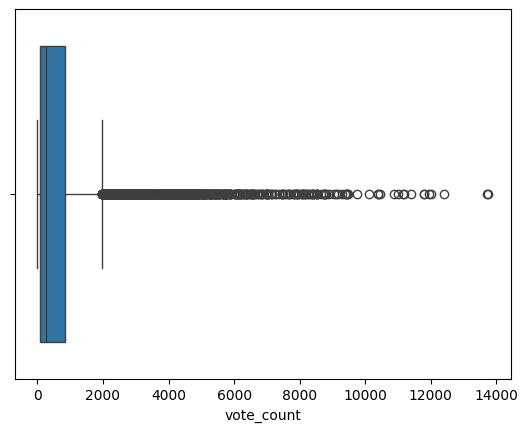

In [22]:
sns.boxplot(data= movies_cleaned_df , x = 'vote_count')

'''

We will use 90th percentile as our cutoff.
In other words, for a movie to feature in the charts,
It must have more votes than at least 90% of the movies in the list.

'''

## 4.. Building Average Weighted Recommendation System !

In [23]:
threshold = movies_cleaned_df['vote_count'].quantile(q = 0.9)

In [24]:
filtered_df = movies_cleaned_df[movies_cleaned_df['vote_count']>=threshold]

In [25]:
filtered_df

,id,budget,genres,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,Unnamed: 4
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...","[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...",5/25/1977,775398007,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",8.100000,6624,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN
2,12,94000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...","[{""id"": 494, ""name"": ""father son relationship""...",en,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",85.688789,"[{""name"": ""Pixar Animation Studios"", ""id"": 3}]",5/30/2003,940335536,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",7.600000,6122,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN
3,13,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]",7/6/1994,677945399,142.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",8.200000,7927,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN
4,14,15000000,"[{""id"": 18, ""name"": ""Drama""}]","[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29...",en,American Beauty,"Lester Burnham, a depressed suburban father in...",80.878605,"[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...",9/15/1999,356296601,122.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,7.900000,3313,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN
6,18,90000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 402, ""name"": ""clone""}, {""id"": 444, ""na...",en,The Fifth Element,"In 2257, a taxi driver is unintentionally give...",109.528572,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",5/7/1997,263920180,126.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",There is no future without it.,7.300000,3885,"[{""cast_id"": 34, ""character"": ""Flynn Rider (vo...","[{""credit_id"": ""52fe46db9251416c91062101"", ""de...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9582,464268,156719309,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 14, ""nam...","[{""id"":393174,""name"":""charcoal""},{""id"":127769,...",en,The Charcoal-Burner's Darkening Influence,A kiln-operator producing charcoal discovers t...,48.506106,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",5/17/2012,257790744,110.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",NaN,5.214528,2594,"[{""cast_id"":1,""character"":""General Matagi"",""cr...","[{""credit_id"":""7eda3169a0118a38ce575c42"",""depa...",NaN
9584,464270,73912397,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...","[{""id"":884844,""name"":""binding""},{""id"":996604,""...",en,The Bookbinder's Consuming Pages,A leather-crafter binding tomes discovers that...,58.587946,"[{""name"": ""Lionsgate"", ""id"": 1632}, {""name"": ""...",3/12/2012,701567495,157.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",NaN,6.078377,10383,"[{""cast_id"":1,""character"":""Pilot"",""credit_id"":...","[{""credit_id"":""bdfeee9fbf7895fda9e7f605"",""depa...",NaN
9591,464277,127619827,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...","[{""id"":218304,""

In [26]:
## R,v,C,m

In [27]:
m = threshold

In [28]:
m

np.float64(2104.800000000001)

In [29]:
R

,vote_average
0,6.500000
1,8.100000
2,7.600000
3,8.200000
4,7.900000
...,...
9598,4.684982
9599,5.098809
9600,6.211067
9601,4.866425


In [30]:
v

,vote_count
0,530
1,6624
2,6122
3,7927
4,3313
...,...
9598,48
9599,1297
9600,1647
9601,225


In [31]:
C

np.float64(6.066097218823389)

In [32]:
filtered_df['weighted_avg'] = ((R*v) + (C*m))/(v+m)

In [33]:
filtered_df

,id,budget,genres,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,Unnamed: 4,weighted_avg
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...","[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...",5/25/1977,775398007,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",8.100000,6624,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN,7.609559
2,12,94000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...","[{""id"": 494, ""name"": ""father son relationship""...",en,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",85.688789,"[{""name"": ""Pixar Animation Studios"", ""id"": 3}]",5/30/2003,940335536,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",7.600000,6122,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN,7.207556
3,13,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]",7/6/1994,677945399,142.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",8.200000,7927,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN,7.752280
4,14,15000000,"[{""id"": 18, ""name"": ""Drama""}]","[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29...",en,American Beauty,"Lester Burnham, a depressed suburban father in...",80.878605,"[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...",9/15/1999,356296601,122.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,7.900000,3313,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN,7.187534
6,18,90000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 402, ""name"": ""clone""}, {""id"": 444, ""na...",en,The Fifth Element,"In 2257, a taxi driver is unintentionally give...",109.528572,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",5/7/1997,263920180,126.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",There is no future without it.,7.300000,3885,"[{""cast_id"": 34, ""character"": ""Flynn Rider (vo...","[{""credit_id"": ""52fe46db9251416c91062101"", ""de...",NaN,6.866410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9582,464268,156719309,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 14, ""nam...","[{""id"":393174,""name"":""charcoal""},{""id"":127769,...",en,The Charcoal-Burner's Darkening Influence,A kiln-operator producing charcoal discovers t...,48.506106,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",5/17/2012,257790744,110.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",NaN,5.214528,2594,"[{""cast_id"":1,""character"":""General Matagi"",""cr...","[{""credit_id"":""7eda3169a0118a38ce575c42"",""depa...",NaN,5.595984
9584,464270,73912397,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...","[{""id"":884844,""name"":""binding""},{""id"":996604,""...",en,The Bookbinder's Consuming Pages,A leather-crafter binding tomes discovers that...,58.587946,"[{""name"": ""Lionsgate"", ""id"": 1632}, {""name"": ""...",3/12/2012,701567495,157.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",NaN,6.078377,10383,"[{""cast_id"":1,""character"":""Pilot"",""credit_id"":...","[{""credit_id"":""bdfeee9fbf7895fda9e7f605"",""depa...",NaN,6.076307
9591,464277,127619827,

In [34]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg'],
      dtype='object')

In [35]:
df_sorted_ranking = filtered_df.sort_values('weighted_avg' , ascending= False).head(20)

In [36]:
df_sorted_ranking.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg'],
      dtype='object')

In [37]:
df_sorted_ranking[['original_title' , 'vote_average', 'vote_count' , 'weighted_avg' , 'popularity']]

,original_title,vote_average,vote_count,weighted_avg,popularity
6608,The Prison Escape Coverup Network,9.860419,10455,9.224558,146.860381
7859,The Warehouse Pallet Swap,9.085233,12389,8.646792,178.607029
7713,Dead Money,9.288525,7683,8.595564,132.773237
8400,The Temporal Artifact,9.625031,4337,8.462181,77.243869
7914,The Bail Money Interception,9.502889,4158,8.347853,46.231763
5081,The Gaslighting Marriage,8.766507,11163,8.338115,168.318482
6309,The Custody Killer,9.056494,6597,8.333174,132.145001
7518,The Aurora Prediction Cache,8.497336,13722,8.174006,177.796208
8084,The Subprime Auto Loan GPS Disable Repossession,9.277441,3517,8.075115,91.354040
9547,The Dust-Collector's Choking Swarm,9.258349,3549,8.069935,59.120126


In [38]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

<Axes: xlabel='weighted_avg', ylabel='original_title'>

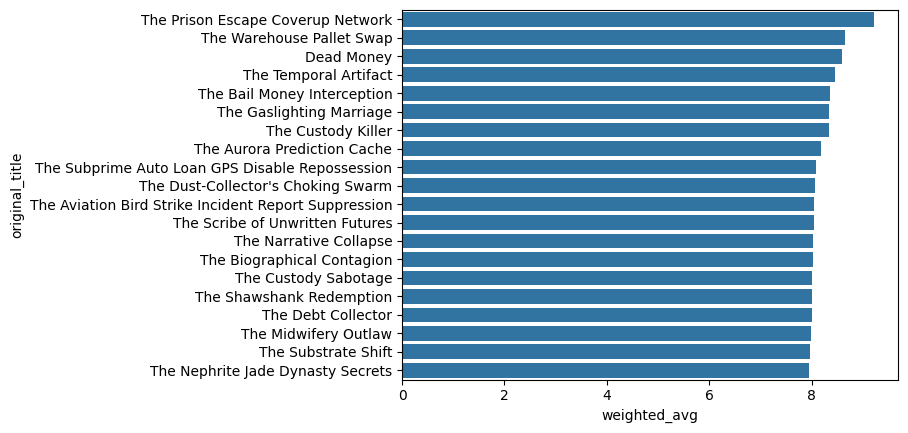

In [39]:
sns.barplot(x = df_sorted_ranking['weighted_avg'] , y = df_sorted_ranking['original_title'])

## 5.. Building Popularity based Recommender System

In [40]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg'],
      dtype='object')

In [41]:
popularity_df = filtered_df.sort_values('popularity' , ascending= False)

<Axes: ylabel='original_title'>

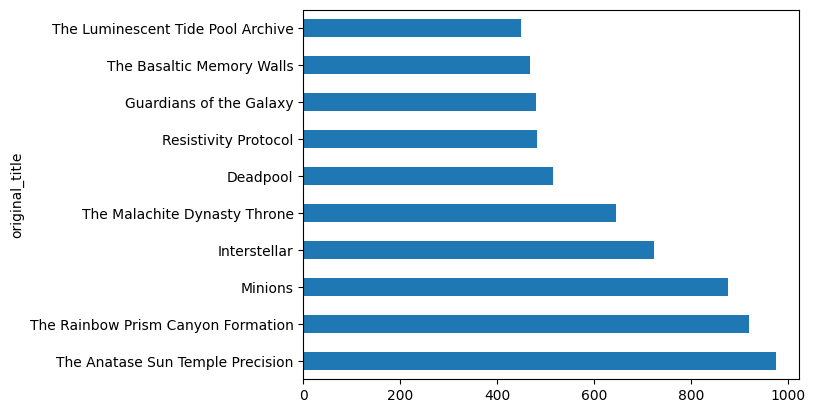

In [42]:
popularity_df.set_index('original_title')['popularity'][0:10].plot.barh()

## Let's Perform Normalization

In [43]:
filtered_df.shape

(961, 20)

In [44]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg'],
      dtype='object')

In [45]:
filtered_df[["weighted_avg","popularity"]][0:10]

,weighted_avg,popularity
1,7.609559,126.393695
2,7.207556,85.688789
3,7.752280,138.133331
4,7.187534,80.878605
6,6.866410,109.528572
9,7.167971,271.972889
10,7.212456,79.754966
14,6.498242,46.875375
15,7.229489,56.481487
17,6.732590,145.847379


In [46]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
scaling = MinMaxScaler()

In [48]:
scaling_values = scaling.fit_transform(filtered_df[['weighted_avg' , 'popularity']])

In [49]:
filtered_df[['weighted_avg_scaled' , 'popularity_scaled']] = scaling_values

In [50]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg', 'weighted_avg_scaled', 'popularity_scaled'],
      dtype='object')

In [51]:
filtered_df.head()

,id,budget,genres,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,Unnamed: 4,weighted_avg,weighted_avg_scaled,popularity_scaled
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...","[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...",5/25/1977,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",8.1,6624,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN,7.609559,0.605973,0.127910
2,12,94000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...","[{""id"": 494, ""name"": ""father son relationship""...",en,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",85.688789,"[{""name"": ""Pixar Animation Studios"", ""id"": 3}]",5/30/2003,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",7.6,6122,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN,7.207556,0.507893,0.086063
3,13,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]",7/6/1994,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",8.2,7927,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN,7.752280,0.640794,0.139980
4,14,15000000,"[{""id"": 18, ""name"": ""Drama""}]","[{""id"": 255, ""name"": ""male nudity""}, {""id"": 29...",en,American Beauty,"Lester Burnham, a depressed suburban father in...",80.878605,"[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...",9/15/1999,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,7.9,3313,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN,7.187534,0.503008,0.081118
6,18,90000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 402, ""name"": ""clone""}, {""id"": 444, ""na...",en,The Fifth Element,"In 2257, a taxi driver is unintentionally give...",109.528572,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",5/7/1997,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",There is no future without it.,7.3,3885,"[{""cast_id"": 34, ""character"": ""Flynn Rider (vo...","[{""credit_id"": ""52fe46db9251416c91062101"", ""de...",NaN,6.866410,0.424660,0.110572


## 7.. Building a Hybrid Recommendation Model Using Weighted Average & Popularity Score

In [52]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg', 'weighted_avg_scaled', 'popularity_scaled'],
      dtype='object')

In [53]:
filtered_df['score_mix'] = filtered_df['weighted_avg_scaled'] * 0.5 + filtered_df['popularity_scaled'] * 0.5

In [54]:
filtered_df.head(3)

,id,budget,genres,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,tagline,vote_average,vote_count,cast,crew,Unnamed: 4,weighted_avg,weighted_avg_scaled,popularity_scaled,score_mix
1,11,11000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...","[{""id"": 803, ""name"": ""android""}, {""id"": 4270, ...",en,Star Wars,Princess Leia is captured and held hostage by ...,126.393695,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...",5/25/1977,...,"A long time ago in a galaxy far, far away...",8.1,6624,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN,7.609559,0.605973,0.127910,0.366942
2,12,94000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...","[{""id"": 494, ""name"": ""father son relationship""...",en,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",85.688789,"[{""name"": ""Pixar Animation Studios"", ""id"": 3}]",5/30/2003,...,"There are 3.7 trillion fish in the ocean, they...",7.6,6122,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN,7.207556,0.507893,0.086063,0.296978
3,13,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]",7/6/1994,...,"The world will never be the same, once you've ...",8.2,7927,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN,7.752280,0.640794,0.139980,0.390387


In [55]:
rank_df = filtered_df.sort_values('score_mix' , ascending= False).head(10)

In [56]:
import plotly.express as px

In [57]:
pip install plotly

In [58]:
px.bar(data_frame= rank_df , x = 'original_title' , y = 'score_mix')

# 8.. Applying TF-IDF(NLP) on text data

In [59]:
filtered_df.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg', 'weighted_avg_scaled', 'popularity_scaled',
       'score_mix'],
      dtype='object')

In [60]:
data = filtered_df.copy()

In [61]:
data.columns

Index(['id', 'budget', 'genres', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'Unnamed: 4',
       'weighted_avg', 'weighted_avg_scaled', 'popularity_scaled',
       'score_mix'],
      dtype='object')

In [62]:
data['overview'].iloc[0]

'Princess Leia is captured and held hostage by the evil Imperial forces in their effort to take over the galactic Empire. Venturesome Luke Skywalker and dashing captain Han Solo team together with the loveable robot duo R2-D2 and C-3PO to rescue the beautiful princess and restore peace and justice in the Empire.'

In [63]:
data['overview'].isnull().sum()

np.int64(0)

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [65]:
tfv = TfidfVectorizer(min_df= 3 ,
               max_features=None ,
               ngram_range= (1 , 3) ,
               stop_words= "english")

In [66]:
tfv_matrix = tfv.fit_transform(data['overview'])

In [67]:
tfv_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18567 stored elements and shape (961, 2649)>

In [68]:
tfv_matrix.shape

(961, 2649)

In [69]:
data['overview'].iloc[0]

'Princess Leia is captured and held hostage by the evil Imperial forces in their effort to take over the galactic Empire. Venturesome Luke Skywalker and dashing captain Han Solo team together with the loveable robot duo R2-D2 and C-3PO to rescue the beautiful princess and restore peace and justice in the Empire.'

In [70]:
tfv_matrix.toarray()[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [71]:
pd.DataFrame(tfv_matrix.toarray())

,0,1,2,3,4,5,6,7,8,9,...,2639,2640,2641,2642,2643,2644,2645,2646,2647,2648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.229201,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.219934,0.0,0.341083,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
959,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000


# 9.. Applying Sigmoid Kernel to Compute Similarity Scores

In [72]:
data['overview']

,overview
1,Princess Leia is captured and held hostage by ...
2,"Nemo, an adventurous young clownfish, is unexp..."
3,A man with a low IQ has accomplished great thi...
4,"Lester Burnham, a depressed suburban father in..."
6,"In 2257, a taxi driver is unintentionally give..."
...,...
9582,A kiln-operator producing charcoal discovers t...
9584,A leather-crafter binding tomes discovers that...
9591,A hide-processor discovers that tanned leather...
9592,A sculptor shaping stone discovers that rocks ...


In [73]:
from sklearn.metrics.pairwise import sigmoid_kernel

In [74]:
sig = sigmoid_kernel(tfv_matrix , tfv_matrix)

In [75]:
sig

array([[0.76175265, 0.76159416, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76175265, 0.76160376, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76160376, 0.76175265, ..., 0.76159416, 0.76159416,
        0.76159416],
       ...,
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76175265, 0.76160376,
        0.76160984],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76160376, 0.76175265,
        0.76163502],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76160984, 0.76163502,
        0.76175265]])

In [76]:
pd.DataFrame(sig)

,0,1,2,3,4,5,6,7,8,9,...,951,952,953,954,955,956,957,958,959,960
0,0.761753,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761601,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
1,0.761594,0.761753,0.761604,0.761603,0.761602,0.761594,0.761594,0.761594,0.761594,0.761603,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
2,0.761594,0.761604,0.761753,0.761601,0.761594,0.761602,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761601,0.761594,0.761594,0.761594,0.761594
3,0.761594,0.761603,0.761601,0.761753,0.761594,0.761611,0.761594,0.761594,0.761609,0.761594,...,0.761594,0.761594,0.761604,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
4,0.761594,0.761602,0.761594,0.761594,0.761753,0.761602,0.761608,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.761594,0.761594,0.761601,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761602,0.761609,0.761601,0.761601,0.761609,0.761753,0.761607,0.761600,0.761611,0.761627
957,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761601,0.761607,0.761610,0.761600,0.761616,0.761607,0.761753,0.761617,0.761618,0.761619
958,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761607,0.761600,0.761600,0.761606,0.761620,0.761600,0.761617,0.761753,0.761604,0.761610
959,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761603,...,0.761606,0.761600,0.761600,0.761605,0.761600,0.761611,0.761618,0.761604,0.761753,0.761635


In [77]:
sig[0]

array([0.76175265, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76160081,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.7615982 , 0.76159416,
       0.76160467, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159816, 0.76160281, 0.76159827,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159992, 0.76160013, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.7616046 , 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76160004, 0.76159416, 0.76159416,
       0.76160415, 0.76159416, 0.76159994, 0.76159727, 0.76159416,
       0.76159744, 0.76159416, 0.76159416, 0.76159812, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159

# 10.. Building Content based Recommendation System

In [78]:
data['original_title']

,original_title
1,Star Wars
2,Finding Nemo
3,Forrest Gump
4,American Beauty
6,The Fifth Element
...,...
9582,The Charcoal-Burner's Darkening Influence
9584,The Bookbinder's Consuming Pages
9591,The Leatherworker's Crawling Hides
9592,The Stoneworker's Grinding Patience


In [79]:
data.index

Index([   1,    2,    3,    4,    6,    9,   10,   14,   15,   17,
       ...
       9570, 9571, 9575, 9580, 9581, 9582, 9584, 9591, 9592, 9596],
      dtype='int64', length=961)

In [80]:
indices = pd.Series(data = data.index , index= data['original_title'])

In [81]:
indices

,0
original_title,
Star Wars,1
Finding Nemo,2
Forrest Gump,3
American Beauty,4
The Fifth Element,6
...,...
The Charcoal-Burner's Darkening Influence,9582
The Bookbinder's Consuming Pages,9584
The Leatherworker's Crawling Hides,9591


In [82]:
indices['John Carter']

np.int64(3481)

In [83]:
indices = pd.Series(
    np.arange(len(data)),
    index=data['original_title']
).drop_duplicates()

sig[indices['John Carter']]

array([0.76159932, 0.76159416, 0.76159416, 0.76159416, 0.76161062,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76160275,
       0.76160952, 0.76159416, 0.76159416, 0.76159416, 0.76159737,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159848, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76160188, 0.76160554, 0.76159416, 0.76159416,
       0.7616002 , 0.76159416, 0.76159416, 0.76159749, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76160156, 0.76160194,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159748, 0.76159416, 0.76159416, 0.76159416, 0.76159883,
       0.76159416, 0.76159416, 0.76160195, 0.76159416, 0.76160477,
       0.76160706, 0.76159857, 0.76159416, 0.76159416, 0.7616004 ,
       0.7616043 , 0.76159416, 0.76159416, 0.76159416, 0.76160236,
       0.76159416, 0.76159884, 0.76159658, 0.761602  , 0.76159416,
       0.76160964, 0.76159416, 0.76159416, 0.76159958, 0.76159

In [84]:
list(enumerate(sig[indices['John Carter']]))

[(0, np.float64(0.7615993226604428)),
 (1, np.float64(0.7615941559557649)),
 (2, np.float64(0.7615941559557649)),
 (3, np.float64(0.7615941559557649)),
 (4, np.float64(0.7616106161491628)),
 (5, np.float64(0.7615941559557649)),
 (6, np.float64(0.7615941559557649)),
 (7, np.float64(0.7615941559557649)),
 (8, np.float64(0.7615941559557649)),
 (9, np.float64(0.7616027476110534)),
 (10, np.float64(0.761609522896751)),
 (11, np.float64(0.7615941559557649)),
 (12, np.float64(0.7615941559557649)),
 (13, np.float64(0.7615941559557649)),
 (14, np.float64(0.7615973681548506)),
 (15, np.float64(0.7615941559557649)),
 (16, np.float64(0.7615941559557649)),
 (17, np.float64(0.7615941559557649)),
 (18, np.float64(0.7615941559557649)),
 (19, np.float64(0.7615941559557649)),
 (20, np.float64(0.7615941559557649)),
 (21, np.float64(0.761598477745781)),
 (22, np.float64(0.7615941559557649)),
 (23, np.float64(0.7615941559557649)),
 (24, np.float64(0.7615941559557649)),
 (25, np.float64(0.7615941559557649))

In [85]:
sigma = sorted(list(enumerate(sig[indices['John Carter']])) , key= lambda x : x[1] , reverse=True)

In [86]:
sigma[0:10]

[(244, np.float64(0.7617526510907975)),
 (235, np.float64(0.7616200651491003)),
 (136, np.float64(0.7616153051359061)),
 (330, np.float64(0.7616144903712526)),
 (313, np.float64(0.7616138168521742)),
 (208, np.float64(0.7616136146083599)),
 (253, np.float64(0.7616121830191925)),
 (229, np.float64(0.7616116075355678)),
 (331, np.float64(0.7616109480319486)),
 (172, np.float64(0.7616107222721531))]

In [87]:
ind = [i[0] for i in sigma[0:10]]

In [88]:
ind

[244, 235, 136, 330, 313, 208, 253, 229, 331, 172]

In [89]:
dataframe = data.reset_index()

In [90]:
dataframe['original_title'][ind]

,original_title
244,John Carter
235,Independence Day: Resurgence
136,Captain America: The First Avenger
330,X-Men: Days of Future Past
313,Captain America: The Winter Soldier
208,The Avengers
253,Star Trek Into Darkness
229,Battleship
331,The Hunger Games: Mockingjay - Part 1
172,Prince of Persia: The Sands of Time


# Automating the model

In [91]:
def give_recommendations(movie_title, model):

    indices = pd.Series(
        np.arange(len(data)),
        index=data['original_title']
    ).drop_duplicates()

    idx = indices[movie_title]

    model_scores = list(enumerate(model[idx]))

    model_scores_sorted = sorted(
        model_scores,
        key=lambda x: x[1],
        reverse=True
    )

    model_scores_10 = model_scores_sorted[1:11]

    movie_indices_10 = [i[0] for i in model_scores_10]

    return data['original_title'].iloc[movie_indices_10]

In [92]:
give_recommendations('Avatar' , sig)

,original_title
3952,Transformers: Age of Extinction
258,E.T. the Extra-Terrestrial
8374,The Structural Imperative
265,Men in Black II
3704,Iron Man 3
9,Pirates of the Caribbean: The Curse of the Bla...
570,Iron Man
9395,The Lamenter's Singing Grief
3323,Ghostbusters
7654,The Fossilized Footprint Trail
